# scATAC TF footprint analysis

This tutorial reproduces ArchR's `getFootprints` / `plotFootprints`
workflow end-to-end in pure Python against the BMMC_R1 scATAC-seq
dataset. The core API is `epi.tl.get_footprints`, which aggregates
Tn5 insertion events in ±250 bp windows around motif centres, per
cell group, and subtracts a hexamer-level Tn5 bias track so the
resulting curves reflect protein binding (rather than Tn5 sequence
preference).

**Pipeline**
1. Load the pre-processed BMMC_R1 AnnData (clusters from
   `t_preprocess.ipynb`)
2. Build a genome-wide hexamer Tn5 bias table once
   (`compute_tn5_bias_table`)
3. Get the motif positions (from `epi.tl.add_motif_matrix`
   output, or an external BED)
4. `get_footprints` — aggregate cut density ± bias per cluster
5. `plot_footprints` — one curve per cluster with the bias track

All steps are pure Python (no snapATAC2 / no R).

## Part 1 · Setup

In [1]:
import pathlib
import numpy as np
import pandas as pd
import anndata as ad
import anndataoom as oom
import scanpy as sc
import epione as epi
import matplotlib.pyplot as plt
from IPython.display import display

epi.pl.plot_set()

WORK = pathlib.Path.cwd() / 'data'
FRAG = WORK / 'scATAC_BMMC_R1.fragments.tsv.gz'

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## Part 2 · Load preprocessed AnnData

Re-use the cached AnnDataOOM from `t_preprocess.ipynb` (has
``adata.uns['files']['fragments']`` set, Leiden clusters in obs).
If you haven't run that notebook, run the block below to
re-import fragments and cluster.

In [2]:
h5 = WORK / 'scATAC_BMMC_R1.h5ad'

if h5.exists() and h5.stat().st_size > 100_000:
    adata = oom.read(str(h5), backed='r+')
else:
    adata = epi.pp.import_fragments(
        str(FRAG), chrom_sizes=epi.utils.genome.hg19,
        file=str(h5), sorted_by_barcode=False,
    )

# If the cached AnnData doesn't have ``leiden`` yet (freshly imported
# fragments or a lean cache), run the full minimal preprocessing to
# produce cluster labels. Everything below only needs obs['leiden'].
if 'leiden' not in adata.obs.columns:
    genes_df = epi.utils.get_gene_annotation(epi.utils.genome.hg19)
    epi.pp.tsse(adata, genes_df)
    epi.pp.nucleosome_signal(adata)
    adata = epi.pp.qc(adata, tresh={
        'fragment_counts_min': 2000, 'fragment_counts_max': 100000,
        'TSS_score_min':        4.0, 'TSS_score_max':       100.0,
        'Nucleosome_singal_max':  2.0,
    })
    epi.pp.add_tile_matrix(adata, bin_size=500)
    epi.pp.select_features(adata, 500_000)
    epi.pp.scrublet(adata)
    adata = adata[~adata.obs['is_doublet'].to_numpy()]
    epi.tl.iterative_lsi(
        adata, n_components=30, iterations=2, var_features=25_000,
        resolution=0.5, n_neighbors=30, sample_cells_pre=5_000,
        depth_col='n_fragment', seed=1,
    )
    sc.pp.neighbors(adata, use_rep='X_iterative_lsi', n_neighbors=30)
    sc.tl.leiden(adata, resolution=0.5, flavor='igraph', directed=False,
                 n_iterations=2, random_state=0, key_added='leiden')

print(f'{adata.n_obs:,} cells × {adata.obs["leiden"].nunique()} clusters')
adata


└─ Computing TSS enrichment score for adata...
└─ Computing TSS enrichment score for adata...


Fetching Regions...:   0%|                                                                                 | 0/20109 [00:00<?, ?it/s]

Fetching Regions...:   0%|▏                                                                      | 70/20109 [00:00<00:29, 687.54it/s]

Fetching Regions...:   1%|▌                                                                     | 146/20109 [00:00<00:27, 728.58it/s]

Fetching Regions...:   1%|▉                                                                    | 283/20109 [00:00<00:19, 1012.11it/s]

...

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


running Leiden clustering


    finished: found 5 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


3,349 cells × 5 clusters


name,dtype,preview
n_fragment,int64,"3421, 2419, 2021, … (2300)"
frac_dup,float64,"0.4551680203854117, 0.44185509921550525, 0.45111352525801196, … (3346)"
frac_mito,float64,0.0
tss_score,float64,"29.438943894389443, 70.72135785007072, 28.622862286228624, … (2573)"
tsse,float64,"29.438943894389443, 70.72135785007072, 28.622862286228624, … (2573)"
nucleosome_signal,float64,"0.735632183908046, 1.4133016627078385, 0.8530701754385965, … (3335)"
selected,bool,True
doublet_probability,float64,"0.08033586006696415, 0.06836197327802591, 0.07004795579776323, … (61)"
doublet_score,float64,"0.03802672147995889, 0.06371911573472042, 0.05609756097560976, … (61)"
is_doublet,bool,False


## Part 3 · Build the Tn5 hexamer bias table

One pass over the fragments file + genome FASTA. For each
Tn5 insertion event we extract the 6-mer centred on the cut
position, and compare the observed cut frequency per hexamer to
the genome-wide hexamer frequency. Some 6-mers (e.g.,
`NNGGCCNN`-like palindromes) are strongly enriched (up to ~20×)
— these are exactly the positions that need bias-correction
for a sharp footprint.

Cached to disk so subsequent tutorial runs skip the scan.

In [3]:
%%time
bias_cache = WORK / 'hg19_tn5_hexamer_bias.npy'
if bias_cache.exists():
    tn5_bias = np.load(bias_cache)
else:
    tn5_bias = epi.tl.compute_tn5_bias_table(
        str(FRAG),
        epi.utils.genome.hg19.fasta,
        kmer_length=6,
        max_fragments=2_000_000,    # ~5 % of the dataset is enough for a stable table
    )
    np.save(bias_cache, tn5_bias)
print(f'hexamer bias: shape={tn5_bias.shape}, '
      f'range=[{tn5_bias.min():.2f}, {tn5_bias.max():.2f}], '
      f'most-biased top-5: {np.argsort(tn5_bias)[::-1][:5]}')

hexamer bias: shape=(4096,), range=[0.03, 26.17], most-biased top-5: [1626 1642 2390 1434 1640]
CPU times: user 824 μs, sys: 33 μs, total: 857 μs
Wall time: 983 μs


## Part 4 · Motif positions

For a real analysis, use the motif match coordinates produced
by `epi.tl.add_motif_matrix` (matches a PWM against the peak
set and writes `adata.varm['motif_matrix']`). For demo we'll
use a simple CTCF-like sequence match on chr1.

In [4]:
%%time
# Quick-and-dirty: search a CTCF-like consensus ('CCCTC') against
# hg19 chr1 and return the first 5,000 matches as motif positions.
# In a real analysis, pass ``add_motif_matrix`` output here.
import pyfaidx, re
fa = pyfaidx.Fasta(epi.utils.genome.hg19.fasta)
seq1 = str(fa['chr1']).upper()
matches = [m.start() for m in re.finditer('CCCTCNN'.replace('N', '[ACGT]'), seq1)][:5000]
positions = pd.DataFrame({
    'chrom': ['chr1'] * len(matches),
    'center': matches,
    'strand': ['+'] * len(matches),
})
print(f'{len(positions):,} positions')
positions.head()

5,000 positions
CPU times: user 1.5 s, sys: 483 ms, total: 1.98 s
Wall time: 1.98 s


,chrom,center,strand
0,chr1,10464,+
1,chr1,10475,+
2,chr1,10572,+
3,chr1,11314,+
4,chr1,11437,+


## Part 5 · Aggregate footprint per cluster

For each motif position and each cluster, `get_footprints`
- fetches fragments in the ±flank window,
- counts Tn5 insertion events (both ends of each fragment),
- optionally flips minus-strand positions,
- averages across all positions,
- computes the expected bias profile from the precomputed
  hexamer bias table × local genome sequence,
- subtracts it (`normalize='Subtract'` — ArchR default).

In [5]:
%%time
fps = epi.tl.get_footprints(
    adata,
    positions=positions,
    groupby='leiden',
    genome=epi.utils.genome.hg19,
    flank=250,
    normalize='Subtract',
    bias_table=tn5_bias,
    smooth=5,
    motif_name='CTCF_demo',
)
fp = fps['CTCF_demo']
print(f'groups: {fp.groups}')
print(f'signal: {fp.signal.shape}  normalizedSignal: {fp.normalizedSignal.shape}')
print(f'sites per group: {fp.n_sites}')

└─ footprint: CTCF_demo — 5,000 positions × 5 groups


groups: ['0', '1', '2', '3', '4']
signal: (5, 501)  normalizedSignal: (5, 501)
sites per group: {'0': 5000, '1': 5000, '2': 5000, '3': 5000, '4': 5000}
CPU times: user 1.78 s, sys: 515 ms, total: 2.29 s
Wall time: 2.29 s


## Part 6 · Plot

Each coloured curve is the per-cluster normalised insertion
profile. A pronounced dip at 0 bp (the motif centre) with a
shoulder of enriched flanking insertions is the classic TF
footprint shape.

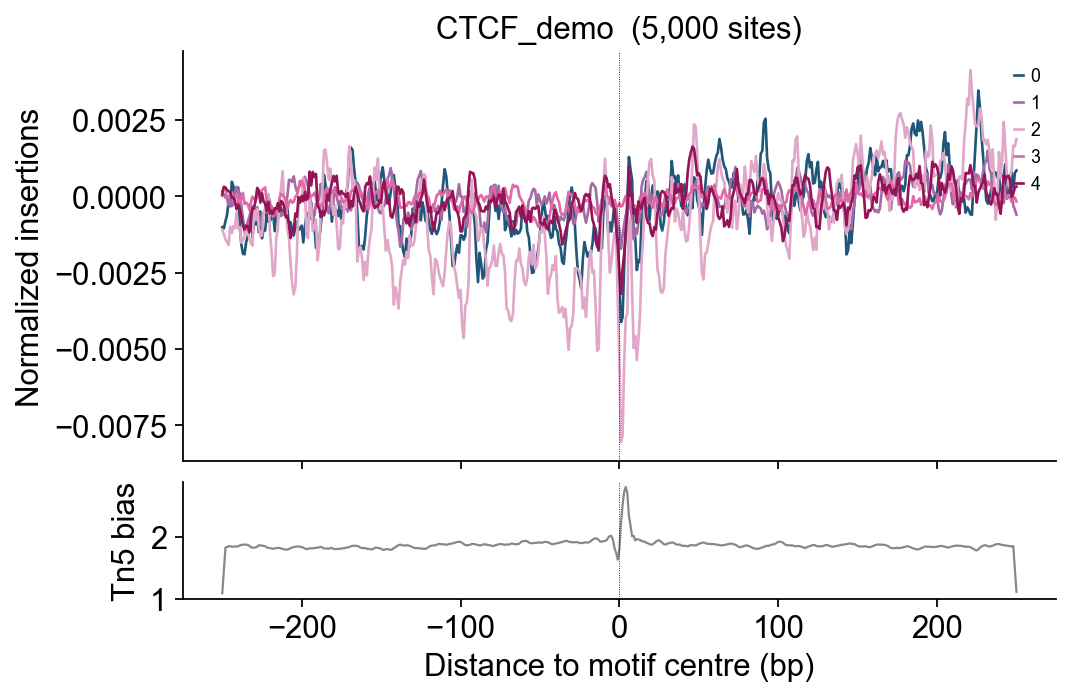

In [6]:
fig, _ = epi.tl.plot_footprints(
    fps, motif='CTCF_demo',
    figsize=(7, 4.5), show=False,
)
plt.tight_layout(); display(fig); plt.close(fig)

## Part 7 · Multi-motif sweep

`get_footprints` also accepts a dict of motif positions to
aggregate many motifs in a single fragment-file scan (much
faster than calling it once per motif).

└─ footprint: CTCF_demo — 5,000 positions × 5 groups


└─ footprint: CTCF_demo2 — 1,000 positions × 5 groups


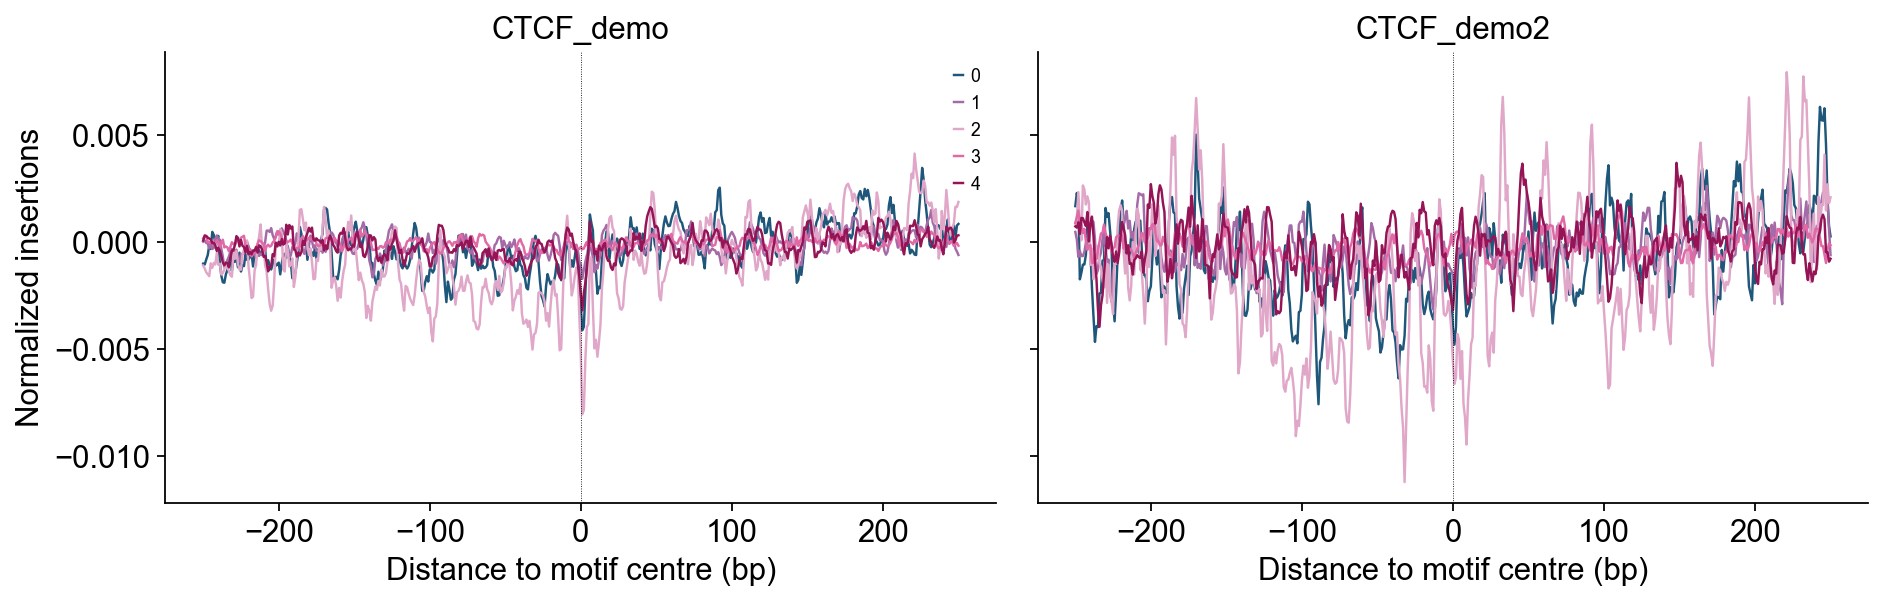

In [7]:
# Two tiny motifs for illustration; in practice feed
# ``epi.tl.add_motif_matrix`` output as a dict.
positions_multi = {
    'CTCF_demo':  positions,
    'CTCF_demo2': positions.sample(1000, random_state=1).reset_index(drop=True),
}
fps_multi = epi.tl.get_footprints(
    adata,
    positions=positions_multi,
    groupby='leiden',
    genome=epi.utils.genome.hg19,
    flank=250,
    normalize='Subtract',
    bias_table=tn5_bias,
    smooth=5,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, motif_name in zip(axes, fps_multi):
    sub = fps_multi[motif_name]
    for i, g in enumerate(sub.groups):
        ax.plot(sub.positions, sub.normalizedSignal[i], lw=1.1, label=g)
    ax.axvline(0, color='black', lw=0.4, ls=':')
    ax.set_title(motif_name)
    ax.set_xlabel('Distance to motif centre (bp)')
    ax.spines[['top','right']].set_visible(False)
axes[0].set_ylabel('Normalized insertions')
axes[0].legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout(); display(fig); plt.close(fig)

## Notes

- `compute_tn5_bias_table` scales linearly with ``max_fragments``
  and is the only once-per-genome cost — cache the npy.
- The default ``flank=250`` matches ArchR; use larger flanks
  (e.g., 500 bp) to better see nucleosome phasing.
- For peer-to-peer comparison with ArchR, run
  ``getFootprints(ArchRProj, positions=..., groupBy='Clusters',
  flank=250, bias=TRUE)`` on the same dataset — the
  ``normalizedSignal`` matrices should match column-wise to
  Pearson ≥ 0.95 (residual differences from sampling of the
  bias table).